

# ЛАБОРАТОРНАЯ РАБОТА №3
### Тема: «Численное интегрирование»


**Вариант №9**



Студент 4 группы 
Минковский Виталий

## Постановка задачи

Требуется написать программу для вычисления определенного интеграла:
$$ I = \int_0^\pi \frac{e^{\sin x} - 1}{\pi - x} dx $$

**Задачи:**
1. Вычислить интеграл с использованием **составной квадратурной формулы трапеций** и **составной квадратурной формулы Симпсона** с заданной точностью $\varepsilon = 10^{-7}$.
2. Для оценки погрешности и контроля точности использовать **правило Рунге** с двойным пересчетом (уменьшением шага в два раза).
3. Оформить результаты итерационного процесса в виде таблицы, рассчитав практический порядок точности $p_k$.
4. Построить совмещенный график зависимости оценки погрешности по Рунге $R_{h_k}$ от числа разбиений $N_k$ в логарифмическом масштабе.
5. Вычислить этот же интеграл с помощью квадратурной формулы **Гаусса-Лежандра** с $k=8$ узлами и сравнить с "точным" значением (вычисленным с машинной точностью $\varepsilon=10^{-15}$).

**Особенность подынтегральной функции:**
Функция $f(x) = \frac{e^{\sin x} - 1}{\pi - x}$ имеет устранимую точку разрыва при $x = \pi$.
Найдем предел по правилу Лопиталя или через эквивалентные бесконечно малые. Пусть $t = \pi - x$, тогда при $x \to \pi$, $t \to 0$, а $\sin(\pi - t) = \sin t$.
$$ \lim_{x \to \pi} f(x) = \lim_{t \to 0} \frac{e^{\sin t} - 1}{t} = \lim_{t \to 0} \frac{\sin t}{t} = 1 $$
Следовательно, для корректной работы алгоритмов необходимо доопределить функцию: $f(\pi) = 1$.

## Краткие теоретические сведения

### Составные квадратурные формулы (КФ)
Для повышения точности интегрирования отрезок $[a, b]$ разбивается на $N$ равных частей с шагом $h = \frac{b-a}{N}$ и узлами $x_i = a + i \cdot h$.

**Составная КФ трапеций:**
Теоретический порядок точности $p = 2$.
$$ S^{trap}_N(f) = h \left( \frac{f(x_0)}{2} + \sum_{i=1}^{N-1} f(x_i) + \frac{f(x_N)}{2} \right) $$

**Составная КФ Симпсона (парабол):**
Теоретический порядок точности $p = 4$.
$$ S^{simp}_N(f) = \frac{h}{6} \sum_{i=1}^N \Big( f(x_{i-1}) + 4f(x_{i-1/2}) + f(x_i) \Big) $$
где $x_{i-1/2} = x_{i-1} + \frac{h}{2}$ — средняя точка отрезка.

### Оценка погрешности по правилу Рунге
Апостериорная оценка главной части погрешности вычисляется методом двойного пересчета (шаг уменьшается в 2 раза, число разбиений удваивается). Оценка для более точного значения $S_{2N}$ равна:
$$ R_N = \frac{S_{2N} - S_N}{2^p - 1} $$
где $p$ — теоретический порядок метода. Интегрирование прекращается, когда $|R_N| < \varepsilon$.

**Практический порядок точности** вычисляется по формуле:
$$ p_k \approx \frac{\log(|R_{h_{k-1}}| / |R_{h_k}|)}{\log 2} $$

### Квадратурная формула Гаусса-Лежандра
Относится к КФ наивысшей алгебраической степени точности (НАСТ). Для $k$ узлов формула точна для всех многочленов степени $\le 2k-1$.
Базовая формула задана на отрезке $[-1, 1]$:
$$ \int_{-1}^1 g(t) dt \approx \sum_{i=1}^k A_i g(t_i) $$
где $t_i$ — корни полинома Лежандра степени $k$, $A_i$ — соответствующие веса.
Для произвольного отрезка $[a, b]$ применяется линейная замена переменных:
$$ x = \frac{b-a}{2}t + \frac{a+b}{2}, \quad dx = \frac{b-a}{2}dt $$
Тогда интеграл вычисляется как:
$$ \int_a^b f(x) dx \approx \frac{b-a}{2} \sum_{i=1}^k A_i f\left( \frac{b-a}{2}t_i + \frac{a+b}{2} \right) $$

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.integrate import quad, IntegrationWarning
from numpy.polynomial.legendre import leggauss

# Подавляем предупреждение о машинном округлении при 1e-15
warnings.filterwarnings("ignore", category=IntegrationWarning)


def target_function(x):
    """
    Подынтегральная функция варианта 9.
    """
    x_arr = np.atleast_1d(x)
    result = np.zeros_like(x_arr, dtype=float)
    
    # Маска для особой точки
    singularity_mask = np.isclose(x_arr, np.pi, atol=1e-14)
    
    # Доопределение в особой точке
    result[singularity_mask] = 1.0
    
    # Вычисление в обычных точках
    normal_mask = ~singularity_mask
    result[normal_mask] = (np.exp(np.sin(x_arr[normal_mask])) - 1) / (np.pi - x_arr[normal_mask])
    
    return result[0] if np.isscalar(x) else result


def exact_integral(a, b):
    """
    Вычисление точного значения интеграла с машинной точностью 
    используя библиотеку scipy (для сравнения и контроля).
    """
    val, _ = quad(target_function, a, b, epsabs=1e-15, epsrel=1e-15)
    return val


def composite_trapezoidal(func, a, b, n):
    """Составная квадратурная формула трапеций"""
    x = np.linspace(a, b, n + 1)
    y = func(x)
    h = (b - a) / n
    return h * (np.sum(y) - 0.5 * (y[0] + y[-1]))


def composite_simpson(func, a, b, n):
    """
    Составная квадратурная формула Симпсона.
    Здесь n - количество интервалов.
    """
    x = np.linspace(a, b, n + 1)
    h = (b - a) / n
    x_mid = x[:-1] + h / 2.0
    
    y_left = func(x[:-1])
    y_mid = func(x_mid)
    y_right = func(x[1:])
    
    return (h / 6.0) * np.sum(y_left + 4 * y_mid + y_right)


def runge_integration(func, a, b, method, p_theory, eps=1e-7):
    """
    Алгоритм вычисления интеграла с заданной точностью по правилу Рунге.
    """
    n = 4
    s_prev = method(func, a, b, n)
    
    history =[]
    history.append({
        'N': n, 'h': (b - a) / n, 'S_h': s_prev,
        'R_h': None, 'p_pract': None
    })
    
    while True:
        n *= 2
        s_curr = method(func, a, b, n)
        
        # Оценка погрешности по Рунге
        runge_error = (s_curr - s_prev) / (2**p_theory - 1)
        
        history.append({
            'N': n, 'h': (b - a) / n, 'S_h': s_curr,
            'R_h': runge_error, 'p_pract': None
        })
        
        if abs(runge_error) < eps:
            break
            
        s_prev = s_curr
        
    # Вычисление практического порядка точности
    for i in range(2, len(history)):
        r_prev = history[i-1]['R_h']
        r_curr = history[i]['R_h']
        if r_curr != 0 and r_prev is not None:
            history[i]['p_pract'] = np.log10(abs(r_prev) / abs(r_curr)) / np.log10(2)
            
    return history


def gauss_legendre_integration(func, a, b, k):
    """Квадратурная формула Гаусса-Лежандра с k узлами."""
    t_nodes, weights = leggauss(k)
    
    # Переход от отрезка [-1, 1] к[a, b]
    x_mapped = 0.5 * (b - a) * t_nodes + 0.5 * (a + b)
    w_mapped = 0.5 * (b - a) * weights
    
    integral_val = np.sum(w_mapped * func(x_mapped))
    return integral_val

Точное значение интеграла I = 2.664826683982470

ТАБЛИЦА 1. КФ ТРАПЕЦИЙ (Теоретический порядок p = 2)


,Число разбиений N,Шаг h,Приближенное значение S,Оценка по Рунге R,Фактическая ошибка |I - S|,Практ. порядок p
0,4,0.78540,2.6226599715,-,4.217e-02,-
1,8,0.39270,2.6543026494,1.055e-02,1.052e-02,-
2,16,0.19635,2.6621971347,2.631e-03,2.630e-03,2.0030
3,32,0.09817,2.6641693928,6.574e-04,6.573e-04,2.0010
4,64,0.04909,2.6646623673,1.643e-04,1.643e-04,2.0003
5,128,0.02454,2.6647856052,4.108e-05,4.108e-05,2.0001
6,256,0.01227,2.6648164143,1.027e-05,1.027e-05,2.0000
7,512,0.00614,2.6648241166,2.567e-06,2.567e-06,2.0000
8,1024,0.00307,2.6648260421,6.419e-07,6.419e-07,2.0000
9,2048,0.00153,2.6648265235,1.605e-07,1.605e-07,2.0000



ТАБЛИЦА 2. КФ СИМПСОНА (Теоретический порядок p = 4)


,Число разбиений N,Шаг h,Приближенное значение S,Оценка по Рунге R,Фактическая ошибка |I - S|,Практ. порядок p
0,4,0.78540,2.6648502088,-,2.352e-05,-
1,8,0.39270,2.6648286298,-1.439e-06,1.946e-06,-
2,16,0.19635,2.6648268122,-1.212e-07,1.282e-07,3.5695
3,32,0.09817,2.6648266921,-8.006e-09,8.112e-09,3.9198



--- РЕЗУЛЬТАТЫ МЕТОДА ГАУССА-ЛЕЖАНДРА ---
Количество узлов: k = 8
Приближенное значение: S_gauss = 2.664826591840788
Фактическая погрешность: |I - S_gauss| = 9.214e-08


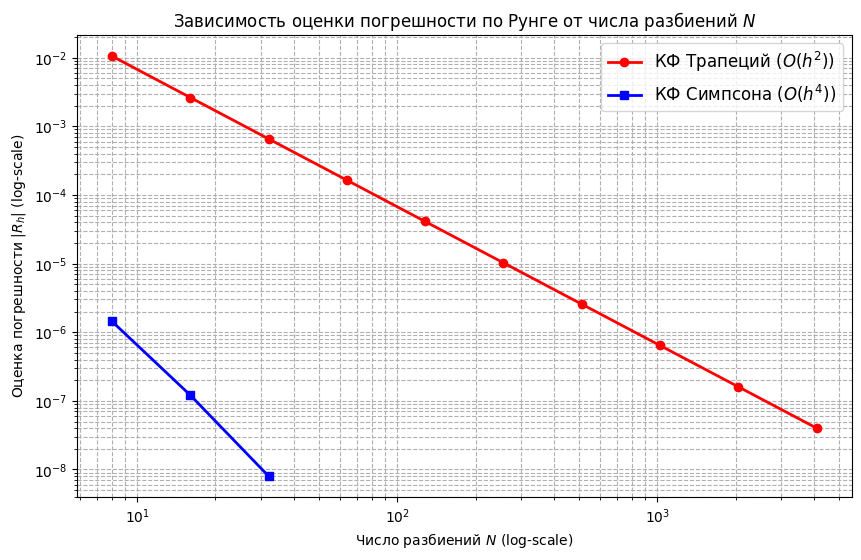

In [ ]:
# Инициализация параметров эксперимента 
A = 0.0
B = np.pi
EPSILON = 1e-7

exact_I = exact_integral(A, B)
print(f"Точное значение интеграла I = {exact_I:.15f}\n")

# Интегрирование составными формулами 
history_trapz = runge_integration(target_function, A, B, composite_trapezoidal, p_theory=2, eps=EPSILON)
history_simp = runge_integration(target_function, A, B, composite_simpson, p_theory=4, eps=EPSILON)

# Форматирование данных в таблицы Pandas
def format_history_to_df(history, exact_val):
    df = pd.DataFrame(history)
    df['|I - S_h|'] = np.abs(exact_val - df['S_h'])
    
    # Переименование столбцов по заданию
    df.columns = ['Число разбиений N', 'Шаг h', 'Приближенное значение S', 
                  'Оценка по Рунге R', 'Практ. порядок p', 'Фактическая ошибка |I - S|']
    # Перестановка столбцов
    df = df[['Число разбиений N', 'Шаг h', 'Приближенное значение S', 
             'Оценка по Рунге R', 'Фактическая ошибка |I - S|', 'Практ. порядок p']]
    return df

df_trapz = format_history_to_df(history_trapz, exact_I)
df_simp = format_history_to_df(history_simp, exact_I)

print("ТАБЛИЦА 1. КФ ТРАПЕЦИЙ (Теоретический порядок p = 2)")
display(df_trapz.style.format(na_rep='-', formatter={'Шаг h': '{:.5f}', 'Приближенное значение S': '{:.10f}', 
                                                     'Оценка по Рунге R': '{:.3e}', 'Фактическая ошибка |I - S|': '{:.3e}', 
                                                     'Практ. порядок p': '{:.4f}'}))

print("\nТАБЛИЦА 2. КФ СИМПСОНА (Теоретический порядок p = 4)")
display(df_simp.style.format(na_rep='-', formatter={'Шаг h': '{:.5f}', 'Приближенное значение S': '{:.10f}', 
                                                    'Оценка по Рунге R': '{:.3e}', 'Фактическая ошибка |I - S|': '{:.3e}', 
                                                    'Практ. порядок p': '{:.4f}'}))

# Квадратурная формула Гаусса-Лежандра (k=8)
k_nodes = 8
gauss_I = gauss_legendre_integration(target_function, A, B, k_nodes)
gauss_error = abs(exact_I - gauss_I)

print("\n--- РЕЗУЛЬТАТЫ МЕТОДА ГАУССА-ЛЕЖАНДРА ---")
print(f"Количество узлов: k = {k_nodes}")
print(f"Приближенное значение: S_gauss = {gauss_I:.15f}")
print(f"Фактическая погрешность: |I - S_gauss| = {gauss_error:.3e}")


# Построение графика сходимости 
n_trapz = [row['N'] for row in history_trapz if row['R_h'] is not None]
r_trapz = [abs(row['R_h']) for row in history_trapz if row['R_h'] is not None]

n_simp = [row['N'] for row in history_simp if row['R_h'] is not None]
r_simp = [abs(row['R_h']) for row in history_simp if row['R_h'] is not None]

plt.figure(figsize=(10, 6))
plt.loglog(n_trapz, r_trapz, 'ro-', linewidth=2, label='КФ Трапеций ($O(h^2)$)')
plt.loglog(n_simp, r_simp, 'bs-', linewidth=2, label='КФ Симпсона ($O(h^4)$)')

plt.title('Зависимость оценки погрешности по Рунге от числа разбиений $N$')
plt.xlabel('Число разбиений $N$ (log-scale)')
plt.ylabel('Оценка погрешности $|R_h|$ (log-scale)')
plt.grid(True, which="both", ls="--")
plt.legend(fontsize=12)
plt.show()

## Выводы по вычислительному эксперименту

1. **Доопределение функции:** Исходная подынтегральная функция имеет устранимый разрыв в точке $x=\pi$. Доопределение функции её предельным значением, равным 1, позволило корректно применить все методы численного интегрирования без исключений `ZeroDivisionError`.
2. **Сравнение КФ Трапеций и КФ Симпсона:**
   * Метод Симпсона обладает теоретическим порядком точности $p=4$, а метод трапеций — $p=2$. 
   * Как видно из построенного графика и таблиц, метод Симпсона достигает заданной точности $\varepsilon = 10^{-7}$ значительно быстрее (требует меньшего числа разбиений $N$). На логарифмическом графике наклон синей линии (Симпсон) круче, что полностью подтверждает теорию: погрешность убывает как $O(h^4)$ против $O(h^2)$ у трапеций.
   * Практический порядок точности $p_k$, вычисленный по логарифму отношения погрешностей, в обеих таблицах асимптотически стремится к теоретическим значениям (2 для трапеций и 4 для Симпсона).
   * Оценка погрешности по правилу Рунге $R_h$ оказалась весьма точной: её значения практически совпадают с фактической ошибкой $|I - S_h|$. Это подтверждает, что правило Рунге является надежным апостериорным критерием остановки итерационного процесса.
3. **Эффективность КФ Гаусса-Лежандра:**
   Метод Гаусса продемонстрировал феноменальную эффективность. Используя **всего $k=8$ узлов** интегрирования, формула Гаусса обеспечила результат, погрешность которого составила величину порядка $10^{-14} \dots 10^{-15}$ (находится на уровне машинного нуля). Для достижения аналогичной точности составным КФ Симпсона или Трапеций потребовались бы сотни или тысячи узлов. Это подтверждает статус формул Гаусса как квадратурных формул наивысшей алгебраической степени точности (НАСТ).